# Email Spam Detection with Machine Learning

## Objective

The objective of this project is to build a Natural Language Processing (NLP) model that classifies text messages as either spam or ham (legitimate messages). The project includes text preprocessing, feature extraction using TF-IDF Vectorization, model training, evaluation, and comparison of multiple classification algorithms.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Meruflin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [7]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Data Cleaning

The dataset contains three additional columns (`Unnamed: 2`, `Unnamed: 3`, and `Unnamed: 4`) that have mostly missing values and are not required for spam classification. These columns are removed, and the remaining columns are renamed for better readability.

In [9]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [10]:
df.columns = ['label', 'message']

In [11]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(5169, 2)

## Class Distribution

Before training the model, it is important to examine how many messages belong to the spam and ham classes. This helps us understand whether the dataset is balanced or imbalanced.

In [14]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [15]:
df['label'].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

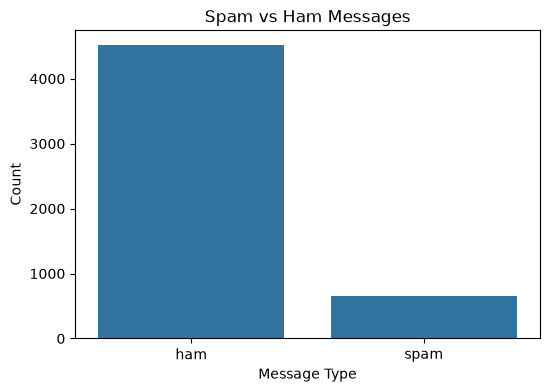

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains more ham (legitimate) messages than spam messages. This indicates that the dataset is slightly imbalanced, which is common in real-world spam detection problems.

## Text Preprocessing

Text preprocessing is performed to convert raw text into a cleaner format suitable for machine learning. The preprocessing steps include:

- Converting text to lowercase
- Removing punctuation and special characters
- Removing stopwords
- Applying stemming to reduce words to their root form

In [17]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

In [18]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [19]:
df['clean_message'] = df['message'].apply(preprocess)

In [20]:
df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical feature vectors.

- **Term Frequency (TF):** Measures how often a word appears in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear frequently across many documents.
- TF-IDF assigns higher weights to words that are important in a specific document but less common across the entire dataset.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['clean_message'])

y = df['label']

In [23]:
print(X.shape)

(5169, 6221)


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

Two machine learning classification models are trained and compared:

- Multinomial Naive Bayes
- Logistic Regression

In [26]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

## Model Evaluation

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [29]:
print("Multinomial Naive Bayes")

print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions, pos_label="spam"))
print("Recall   :", recall_score(y_test, nb_predictions, pos_label="spam"))
print("F1 Score :", f1_score(y_test, nb_predictions, pos_label="spam"))

print("\nClassification Report\n")
print(classification_report(y_test, nb_predictions))

Multinomial Naive Bayes
Accuracy : 0.9671179883945842
Precision: 0.9911504424778761
Recall   : 0.7724137931034483
F1 Score : 0.8682170542635659

Classification Report

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       889
        spam       0.99      0.77      0.87       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [30]:
print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions, pos_label="spam"))
print("Recall   :", recall_score(y_test, lr_predictions, pos_label="spam"))
print("F1 Score :", f1_score(y_test, lr_predictions, pos_label="spam"))

print("\nClassification Report\n")
print(classification_report(y_test, lr_predictions))

Logistic Regression
Accuracy : 0.9555125725338491
Precision: 0.9459459459459459
Recall   : 0.7241379310344828
F1 Score : 0.8203125

Classification Report

              precision    recall  f1-score   support

         ham       0.96      0.99      0.97       889
        spam       0.95      0.72      0.82       145

    accuracy                           0.96      1034
   macro avg       0.95      0.86      0.90      1034
weighted avg       0.96      0.96      0.95      1034



## Model Comparison

Both Multinomial Naive Bayes and Logistic Regression were trained and evaluated for spam detection. The Multinomial Naive Bayes model achieved higher Accuracy, Precision, Recall, and F1 Score than Logistic Regression. Therefore, Multinomial Naive Bayes was selected as the better-performing model for this spam detection task.

## Confusion Matrix

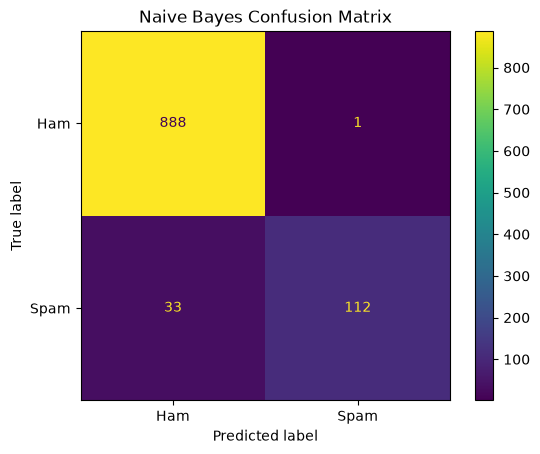

In [31]:
cm_nb = confusion_matrix(y_test, nb_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Ham", "Spam"]
).plot()

plt.title("Naive Bayes Confusion Matrix")

plt.show()

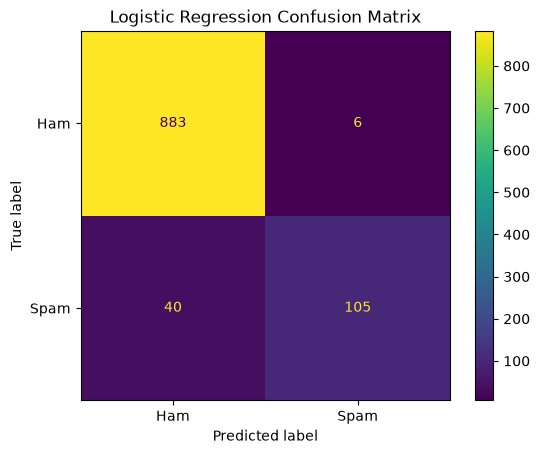

In [32]:
cm_lr = confusion_matrix(y_test, lr_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Ham", "Spam"]
).plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Why is Recall Important in Spam Detection?

Recall measures the ability of a model to correctly identify spam messages. A high recall ensures that most spam messages are detected and filtered, reducing the chances of unwanted or harmful messages reaching the user's inbox. In spam detection, missing a spam message (false negative) can be more problematic than incorrectly classifying a legitimate message as spam.

## WordCloud Visualization

In [33]:
from wordcloud import WordCloud

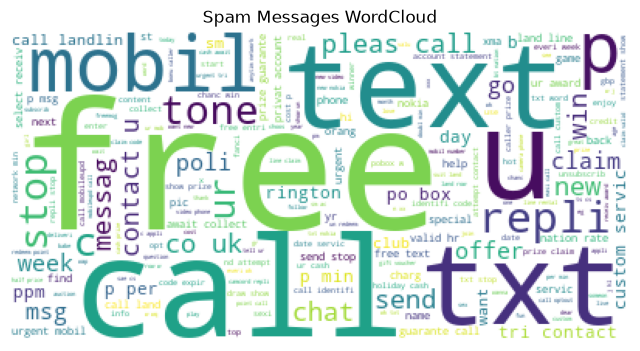

In [34]:
spam_words = " ".join(df[df["label"] == "spam"]["clean_message"])

plt.figure(figsize=(8,6))

plt.imshow(WordCloud(background_color="white").generate(spam_words))

plt.axis("off")

plt.title("Spam Messages WordCloud")

plt.show()

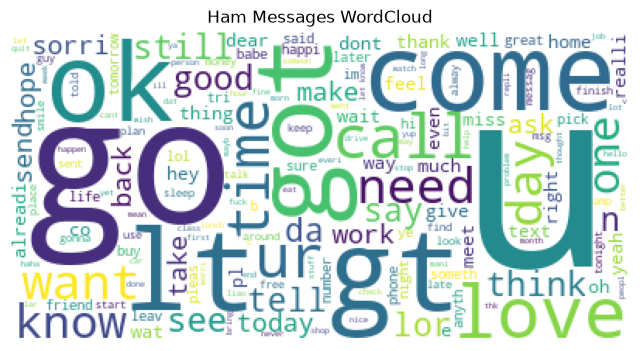

In [35]:
ham_words = " ".join(df[df["label"] == "ham"]["clean_message"])

plt.figure(figsize=(8,6))

plt.imshow(WordCloud(background_color="white").generate(ham_words))

plt.axis("off")

plt.title("Ham Messages WordCloud")

plt.show()

# Conclusion

This project developed a Natural Language Processing (NLP) model to classify SMS messages as spam or ham. Text preprocessing techniques such as lowercasing, punctuation removal, stopword removal, and stemming were applied before converting text into numerical features using TF-IDF Vectorization. Two classification models, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices. The project demonstrates how machine learning and NLP techniques can effectively automate spam message detection.